In [2]:
from google.colab import drive
drive.mount('/content/drive')

!ls -lh "/content/drive/MyDrive"

Mounted at /content/drive
total 2.7G
-rw------- 1 root root 169K Oct  2  2021 '02 35x45 .jpg'
-rw------- 1 root root  37K Mar 25  2023  0s_to_1_5s_Fighting_Sound_Effect.mp3
-rw------- 1 root root 286K Mar 25  2023 '10 second chill music 7  best to relax to.mp3'
-rw------- 1 root root 7.5M Dec 17  2024 '22_l1_insolationenergy (1).pdf'
-rw------- 1 root root 5.2M Dec  7  2024 '22_l1_insolationenergy (2).pdf'
-rw------- 1 root root 5.2M Dec  7  2024  22_l1_insolationenergy.pdf
-rw------- 1 root root 493K Jul 23  2025  230008020_2025_autumn_copy.pdf
-rw------- 1 root root 351K Sep 25  2023  230008020_MannanMahajan_A4.pdf
-rw------- 1 root root 263K Jun 12  2023 '23116271506102005 (1).pdf'
-rw------- 1 root root  13M Feb  1  2026  2453-Strenth-ai.mp4
-rw------- 1 root root 224K Mar 25  2023 '2 Hours Later Sound Effect.mp4'
-rw------- 1 root root  65K Mar 25  2023 '2 sec. INTRO.mp3'
-rw------- 1 root root  179 Mar  2  2025 '48 Hr CEO challenge.gdoc'
-rw------- 1 root root 130K Mar 25  2023 '

In [3]:
import pandas as pd

path = "/content/drive/MyDrive/online_retail_II.csv"
df = pd.read_csv(path, parse_dates=["InvoiceDate"])

print(df.shape)
print(df.columns.tolist())
df.head()

(1067371, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


##**Data Cleaning**

In [4]:
print(df.dtypes)
print(df["InvoiceDate"].min(), df["InvoiceDate"].max())
print(df.isna().sum())
print(len(df))

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object
2009-12-01 07:45:00 2011-12-09 12:50:00
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
1067371


In [5]:
counts = df["Country"].value_counts()
print(counts.head(10))
print(counts.shape)
print((counts / len(df)).head(5))

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64
(43,)
Country
United Kingdom    0.919390
EIRE              0.016738
Germany           0.016512
France            0.013426
Netherlands       0.004816
Name: count, dtype: float64


In [6]:
df["is_cancel"] = df["Invoice"].astype(str).str.startswith("C")

print(df["is_cancel"].sum())
print(df["is_cancel"].mean()) #this is giving the proportion of total orders which is cancelled
print(df.loc[df["is_cancel"], "Quantity"].describe())
df.loc[df["is_cancel"]].head()

19494
0.018263565339511754
count    19494.000000
mean       -25.186827
std        805.104908
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max          1.000000
Name: Quantity, dtype: float64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancel
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True


In [7]:
cancels = df.loc[df["is_cancel"]]
#this is to remove the anomalies as max has come to be 1.0, which means one of the cancelled order is returning +ve quantity
print(cancels.loc[cancels["Quantity"] > 0])
print(cancels.nsmallest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]])

       Invoice StockCode Description  Quantity         InvoiceDate   Price  \
76799  C496350         M      Manual         1 2010-02-01 08:24:00  373.57   

       Customer ID         Country  is_cancel  
76799          NaN  United Kingdom       True  
         Invoice StockCode                          Description  Quantity  \
1065883  C581484     23843          PAPER CRAFT , LITTLE BIRDIE    -80995   
587085   C541433     23166       MEDIUM CERAMIC TOP STORAGE JAR    -74215   
507225   C536757     84347  ROTATING SILVER ANGELS T-LIGHT HLDR     -9360   
529729   C536757     84347  ROTATING SILVER ANGELS T-LIGHT HLDR     -9360   
359669   C524235     21088         SET/6 FRUIT SALAD PAPER CUPS     -7128   

         Price  Customer ID  
1065883   2.08      16446.0  
587085    1.04      12346.0  
507225    0.03      15838.0  
529729    0.03      15838.0  
359669    0.08      14277.0  


In [8]:
df["Revenue"] = df["Quantity"] * df["Price"]

returns_value = df.loc[df["is_cancel"], "Revenue"].sum()
gross = df.loc[~df["is_cancel"], "Revenue"].sum()

print(returns_value, gross)
print(abs(returns_value) / gross)

-1526667.86 20813918.428
0.07334841179862821


In [9]:
cancels = df.loc[df["is_cancel"]]
normal = cancels.loc[cancels["Quantity"] > -1000]

print(normal["Revenue"].sum() / gross)
print(cancels["Revenue"].sum() / gross)

top_returns = cancels.groupby("Description")["Revenue"].agg(["sum", "count"])
print(top_returns.sort_values("sum").head(10))

-0.0595592412975128
-0.07334841179862821
                                          sum  count
Description                                         
Manual                             -423512.60    538
AMAZON FEE                         -294772.71     39
PAPER CRAFT , LITTLE BIRDIE        -168469.60      1
MEDIUM CERAMIC TOP STORAGE JAR      -77479.64     10
Bank Charges                        -33997.91     63
REGENCY CAKESTAND 3 TIER            -16749.60    347
POSTAGE                             -15256.42    229
Discount                            -13882.43    172
WHITE HANGING HEART T-LIGHT HOLDER   -9389.65    135
CRUK Commission                      -7933.43     16


In [10]:
cancels = df.loc[df["is_cancel"]]
normal = cancels.loc[cancels["Quantity"] > -1000]

print(normal["Revenue"].sum() / gross)
print(cancels["Revenue"].sum() / gross)

top_returns = cancels.groupby("Description")["Revenue"].agg(["sum", "count"])
print(top_returns.sort_values("sum").head(10))

-0.0595592412975128
-0.07334841179862821
                                          sum  count
Description                                         
Manual                             -423512.60    538
AMAZON FEE                         -294772.71     39
PAPER CRAFT , LITTLE BIRDIE        -168469.60      1
MEDIUM CERAMIC TOP STORAGE JAR      -77479.64     10
Bank Charges                        -33997.91     63
REGENCY CAKESTAND 3 TIER            -16749.60    347
POSTAGE                             -15256.42    229
Discount                            -13882.43    172
WHITE HANGING HEART T-LIGHT HOLDER   -9389.65    135
CRUK Commission                      -7933.43     16


In [11]:
codes = df["StockCode"].astype(str)
odd = codes[~codes.str.match(r"^\d{5}")]

print(odd.value_counts())

StockCode
POST         2122
DOT          1446
M            1421
C2            282
D             177
             ... 
DCGS0074        1
DCGS0073        1
DCGS0071        1
DCGS0066P       1
DCGS0067        1
Name: count, Length: 62, dtype: int64


So here we are trying to find those rows which are just accounting related like fees/post/amazon/manual.
To do that we are trying to map out those columns whose StockCode isn't like normal items.






In [12]:
pd.set_option("display.max_rows", 100)

summary = df.loc[~codes.str.match(r"^\d{5}")].groupby("StockCode").agg(
    rows=("Invoice", "size"),
    desc=("Description", "first"),
    revenue=("Revenue", "sum"),
)
print(summary.sort_values("rows", ascending=False))

              rows                                 desc     revenue
StockCode                                                          
POST          2122                              POSTAGE  112341.000
DOT           1446                       DOTCOM POSTAGE  322647.470
M             1421                               Manual  -82796.320
C2             282                             CARRIAGE   13386.000
D              177                             Discount  -13484.540
S              104                              SAMPLES   -6065.800
BANK CHARGES   102                         Bank Charges  -35562.629
ADJUST          67  Adjustment by john on 26/01/2010 16    6835.240
AMAZONFEE       43                           AMAZON FEE -260763.580
DCGS0058        31                     MISO PRETTY  GUM      34.820
gift_0001_20    29   Dotcomgiftshop Gift Voucher £20.00     471.060
gift_0001_30    29   Dotcomgiftshop Gift Voucher £30.00     610.090
DCGSSGIRL       25                              

In [13]:
admin = ["POST", "DOT", "C2", "D", "S", "M", "B", "CRUK", "PADS","ADJUST", "ADJUST2", "BANK CHARGES", "AMAZONFEE", "TEST001", "TEST002", "GIFT"]

is_product = codes.str.match(r"^\d{5}") & ~codes.str.upper().isin(admin)

print(len(df) - is_product.sum())
print(df.loc[~is_product, "Revenue"].sum())

6093
-95225.442


In [14]:
df = df.loc[is_product].copy()

cancels = df["is_cancel"]
returns_value = df.loc[cancels, "Revenue"].sum()
gross = df.loc[~cancels, "Revenue"].sum()

print(len(df))
print(returns_value, gross)
print(abs(returns_value) / gross)

1061278
-726519.3899999999 20108995.400000002
0.03612907435445531


In [15]:
key = ["Customer ID", "StockCode"]

purchases = df.loc[~df["is_cancel"]].copy()
returns = df.loc[df["is_cancel"]].copy()

returns["qty_abs"] = returns["Quantity"].abs()
purchases["qty_abs"] = purchases["Quantity"]

print(len(purchases), len(returns))
print(returns["Customer ID"].isna().sum())

1042993 18285
352


In [16]:
purchases = purchases.reset_index().rename(columns={"index": "purchase_idx"})

matched = returns.reset_index().merge(
    purchases[["purchase_idx", "Customer ID", "StockCode", "qty_abs", "InvoiceDate"]],
    on=["Customer ID", "StockCode", "qty_abs"],
    suffixes=("_ret", "_pur"),
)

matched = matched.loc[matched["InvoiceDate_pur"] <= matched["InvoiceDate_ret"]]
print(len(matched), matched["index"].nunique())

13885 6826


In [17]:
returns["is_matched"] = returns.index.isin(set(matched["index"]))

print(returns.groupby("is_matched")["Revenue"].agg(["sum", "count"]))
print(returns.loc[returns["is_matched"]].nsmallest(3, "Quantity")[["Description", "Quantity", "Revenue"]])

                  sum  count
is_matched                  
False      -158591.49  11459
True       -567927.90   6826
                                 Description  Quantity   Revenue
1065883          PAPER CRAFT , LITTLE BIRDIE    -80995 -168469.6
587085        MEDIUM CERAMIC TOP STORAGE JAR    -74215  -77183.6
507225   ROTATING SILVER ANGELS T-LIGHT HLDR     -9360    -280.8


In [18]:
matched = matched.sort_values("InvoiceDate_pur").drop_duplicates("index", keep="last")

drop_idx = set(matched["index"]) | set(matched["purchase_idx"])
before = len(df)
df = df.drop(index=drop_idx)
df = df.loc[~df["is_cancel"]].copy()

print(before, len(df), before - len(df))

1061278 1036493 24785


In [19]:
print((df["Price"] <= 0).sum())
print(df.loc[df["Price"] < 0])
print(df.loc[df["Price"] == 0, "Quantity"].describe())

6113
Empty DataFrame
Columns: [Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country, is_cancel, Revenue]
Index: []
count     6113.000000
mean       -52.817111
std        632.982204
min      -9600.000000
25%        -33.000000
50%         -3.000000
75%          2.000000
max      12540.000000
Name: Quantity, dtype: float64


In [20]:
neg = df["Quantity"] <= 0

print(neg.sum())
print(df.loc[neg, "Price"].describe())
print(df.loc[neg & (df["Price"] > 0), ["Description", "Quantity", "Price", "Customer ID"]].head())

3426
count    3426.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Price, dtype: float64
Empty DataFrame
Columns: [Description, Quantity, Price, Customer ID]
Index: []


In [21]:
df = df.loc[(df["Price"] > 0) & (df["Quantity"] > 0)].copy()
df = df.drop(columns=["is_cancel"])

print(len(df))
print(df["Revenue"].sum())
print(df["Invoice"].nunique(), df["Customer ID"].nunique())

1030380
19499695.02999999
39232 5839


In [22]:
df["Customer ID"] = df["Customer ID"].astype("Int64").astype(str)

known = df.loc[df["Customer ID"] != "<NA>"].copy()

print(len(df), len(known))
print(len(known) / len(df))
print(known["Revenue"].sum() / df["Revenue"].sum())

1030380 796429
0.772946873968827
0.8632235701175482


In [23]:
df["has_id"] = df["Customer ID"] != "<NA>"

by_group = df.groupby("has_id").agg(
    rows=("Invoice", "size"),
    orders=("Invoice", "nunique"),
    revenue=("Revenue", "sum"),
    avg_price=("Price", "mean"),
    avg_qty=("Quantity", "mean"),
)
by_group["aov"] = by_group["revenue"] / by_group["orders"]
by_group["lines_per_order"] = by_group["rows"] / by_group["orders"]
print(by_group)

          rows  orders      revenue  avg_price    avg_qty         aov  \
has_id                                                                  
False   233951    2899   2667098.67   4.733170   3.030130  920.006440   
True    796429   36333  16832596.36   2.909945  12.919684  463.286719   

        lines_per_order  
has_id                   
False         80.700586  
True          21.920265  


In [24]:
anon = df.loc[~df["has_id"]]

per_invoice = anon.groupby("Invoice").agg(
    lines=("StockCode", "size"),
    revenue=("Revenue", "sum"),
    days=("InvoiceDate", lambda s: s.dt.normalize().nunique()),
)

print(per_invoice["lines"].describe())
print(per_invoice["days"].value_counts().head())
print(per_invoice.nlargest(5, "lines"))

count    2899.000000
mean       80.700586
std       135.860997
min         1.000000
25%         3.000000
50%        20.000000
75%       125.000000
max      1348.000000
Name: lines, dtype: float64
days
1    2899
Name: count, dtype: int64
         lines   revenue  days
Invoice                       
537434    1348  14544.82     1
538071    1298  12733.16     1
537638    1199  10910.38     1
537237    1189  12902.94     1
536876    1183  12736.61     1


##**Core business metrics**

In [25]:
kpi = {
    "revenue": known["Revenue"].sum(),
    "orders": known["Invoice"].nunique(),
    "customers": known["Customer ID"].nunique(),
    "lines": len(known),
}
kpi["aov"] = kpi["revenue"] / kpi["orders"]
kpi["orders_per_customer"] = kpi["orders"] / kpi["customers"]
kpi["revenue_per_customer"] = kpi["revenue"] / kpi["customers"]

for k, v in kpi.items():
    print(k, round(v, 2))

revenue 16832596.36
orders 36333
customers 5839
lines 796429
aov 463.29
orders_per_customer 6.22
revenue_per_customer 2882.79


In [26]:
known["month"] = known["InvoiceDate"].dt.to_period("M")

monthly = known.groupby("month").agg(
    revenue=("Revenue", "sum"),
    orders=("Invoice", "nunique"),
    customers=("Customer ID", "nunique"),
)
monthly["aov"] = monthly["revenue"] / monthly["orders"]

print(monthly)

            revenue  orders  customers         aov
month                                             
2009-12   673905.71    1491        951  451.982368
2010-01   531033.84     950        697  558.982989
2010-02   490551.96    1081        768  453.794598
2010-03   660863.78    1497       1047  441.458771
2010-04   578736.91    1308        937  442.459411
2010-05   581141.61    1355        962  428.886797
2010-06   612123.91    1471       1033  416.127743
2010-07   570686.23    1348        923  423.357737
2010-08   576442.44    1268        907  454.607603
2010-09   792868.70    1644       1130  482.280231
2010-10   987132.47    2087       1486  472.991121
2010-11  1130600.26    2552       1601  443.025180
2010-12   867987.16    1388        883  625.350980
2011-01   458379.33     975        737  470.132646
2011-02   440261.06     987        756  446.059838
2011-03   577035.90    1303        970  442.851804
2011-04   449412.27    1129        848  398.062241
2011-05   653179.21    1528    

In [27]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("outputs/figures").mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

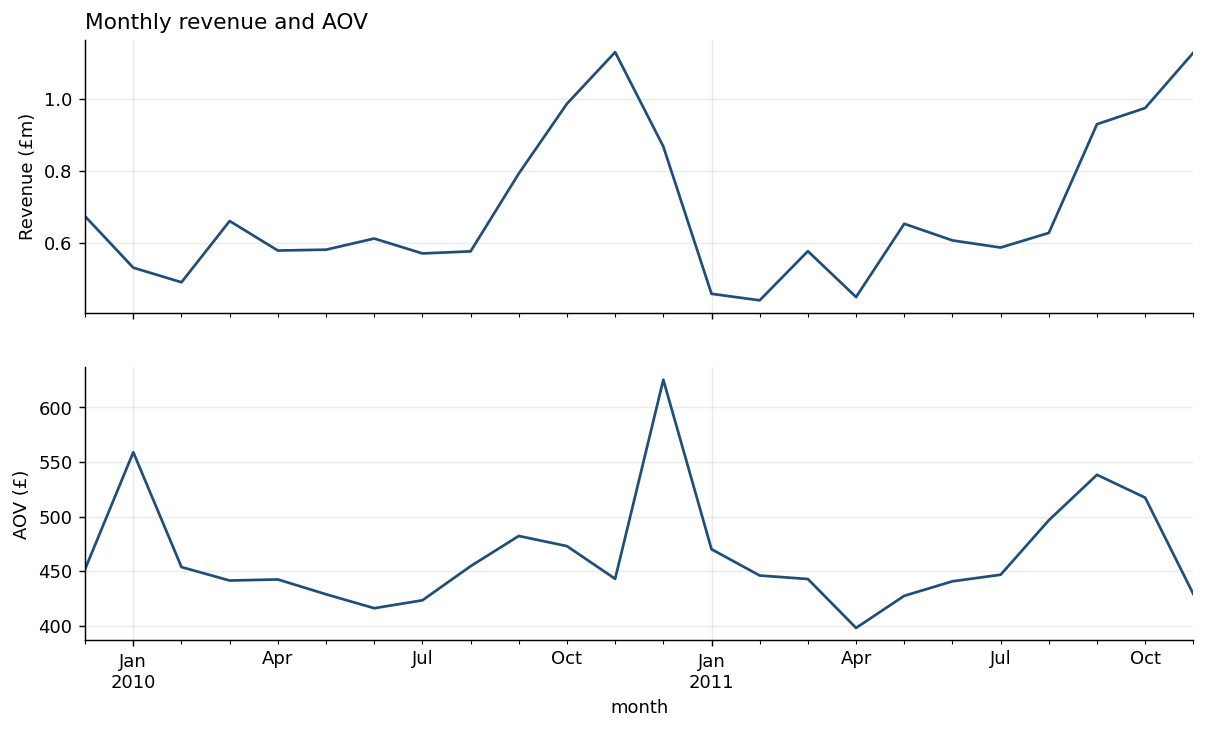

In [28]:
from pathlib import Path
import matplotlib.pyplot as plt

Path("outputs/figures").mkdir(parents=True, exist_ok=True)
m = monthly.iloc[:-1]

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
m["revenue"].div(1e6).plot(ax=ax[0], color="#1f4e79")
m["aov"].plot(ax=ax[1], color="#1f4e79")

ax[0].set_ylabel("Revenue (£m)")
ax[1].set_ylabel("AOV (£)")
ax[0].set_title("Monthly revenue and AOV", loc="left")
fig.savefig("outputs/figures/monthly_trend.png", bbox_inches="tight")

In [29]:
cust_rev = known.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)

share = cust_rev.cumsum() / cust_rev.sum()
n = len(cust_rev)

for pct in [0.01, 0.05, 0.10, 0.20, 0.50]:
    print(pct, round(share.iloc[int(n * pct) - 1], 3))

0.01 0.31
0.05 0.51
0.1 0.631
0.2 0.767
0.5 0.934


In [30]:
first_month = known.groupby("Customer ID")["month"].min()
known["cohort"] = known["Customer ID"].map(first_month)
known["is_new"] = known["cohort"] == known["month"]

split = known.groupby(["month", "is_new"])["Revenue"].sum().unstack()
split.columns = ["returning", "new"]
print(split)
print((split["new"] / split.sum(axis=1)).round(3))

          returning        new
month                         
2009-12         NaN  673905.71
2010-01   373550.56  157483.28
2010-02   324578.05  165973.91
2010-03   452829.42  208034.36
2010-04   456633.21  122103.70
2010-05   472262.18  108879.43
2010-06   488124.61  123999.30
2010-07   499541.66   71144.57
2010-08   516116.17   60326.27
2010-09   637301.97  155566.73
2010-10   821501.33  165631.14
2010-11   975775.32  154824.94
2010-12   828367.33   39619.83
2011-01   427731.42   30647.91
2011-02   397149.79   43111.27
2011-03   502737.05   74298.85
2011-04   409760.45   39651.82
2011-05   604861.14   48318.07
2011-06   563532.67   43382.59
2011-07   544657.80   42399.77
2011-08   583588.98   44193.45
2011-09   838466.17   91749.90
2011-10   878489.52   96737.68
2011-11  1049139.63   80042.34
2011-12   320645.98   23227.13
month
2009-12    1.000
2010-01    0.297
2010-02    0.338
2010-03    0.315
2010-04    0.211
2010-05    0.187
2010-06    0.203
2010-07    0.125
2010-08    0.105
2010

In [31]:
new_counts = known.groupby("cohort")["Customer ID"].nunique()

summary = pd.DataFrame({
    "new_customers": new_counts,
    "active_customers": monthly["customers"],
    "revenue": monthly["revenue"],
})
print(summary)

         new_customers  active_customers     revenue
2009-12            951               951   673905.71
2010-01            366               697   531033.84
2010-02            374               768   490551.96
2010-03            441              1047   660863.78
2010-04            294               937   578736.91
2010-05            253               962   581141.61
2010-06            267              1033   612123.91
2010-07            187               923   570686.23
2010-08            162               907   576442.44
2010-09            236              1130   792868.70
2010-10            369              1486   987132.47
2010-11            327              1601  1130600.26
2010-12             77               883   867987.16
2011-01             73               737   458379.33
2011-02            126               756   440261.06
2011-03            178               970   577035.90
2011-04            106               848   449412.27
2011-05            113              1051   653

##**Cohort Retention**

In [32]:
known["cohort_index"] = (known["month"] - known["cohort"]).apply(lambda x: x.n)

print(known["cohort_index"].describe())
print(known["cohort_index"].value_counts().sort_index().head(8))

count    796429.000000
mean          8.073874
std           7.178552
min           0.000000
25%           1.000000
50%           7.000000
75%          13.000000
max          24.000000
Name: cohort_index, dtype: float64
cohort_index
0    168297
1     40191
2     40361
3     40800
4     35987
5     34302
6     32889
7     31507
Name: count, dtype: int64


In [33]:
cohorts = known.groupby(["cohort", "cohort_index"])["Customer ID"].nunique().unstack()

sizes = cohorts[0]
retention = cohorts.divide(sizes, axis=0)

print(cohorts.iloc[:6, :6])
print(retention.iloc[:6, :6].round(3))

cohort_index      0      1      2      3      4      5
cohort                                                
2009-12       951.0  331.0  317.0  402.0  359.0  342.0
2010-01       366.0   77.0  116.0  116.0   99.0  114.0
2010-02       374.0   88.0   85.0  110.0   92.0   73.0
2010-03       441.0   83.0  102.0  107.0  101.0   89.0
2010-04       294.0   56.0   56.0   47.0   54.0   65.0
2010-05       253.0   39.0   43.0   45.0   45.0   65.0
cohort_index    0      1      2      3      4      5
cohort                                              
2009-12       1.0  0.348  0.333  0.423  0.377  0.360
2010-01       1.0  0.210  0.317  0.317  0.270  0.311
2010-02       1.0  0.235  0.227  0.294  0.246  0.195
2010-03       1.0  0.188  0.231  0.243  0.229  0.202
2010-04       1.0  0.190  0.190  0.160  0.184  0.221
2010-05       1.0  0.154  0.170  0.178  0.178  0.257


In [34]:
from pathlib import Path

OUT = Path("/content/drive/MyDrive/ecommerce-analytics/figures")
OUT.mkdir(parents=True, exist_ok=True)

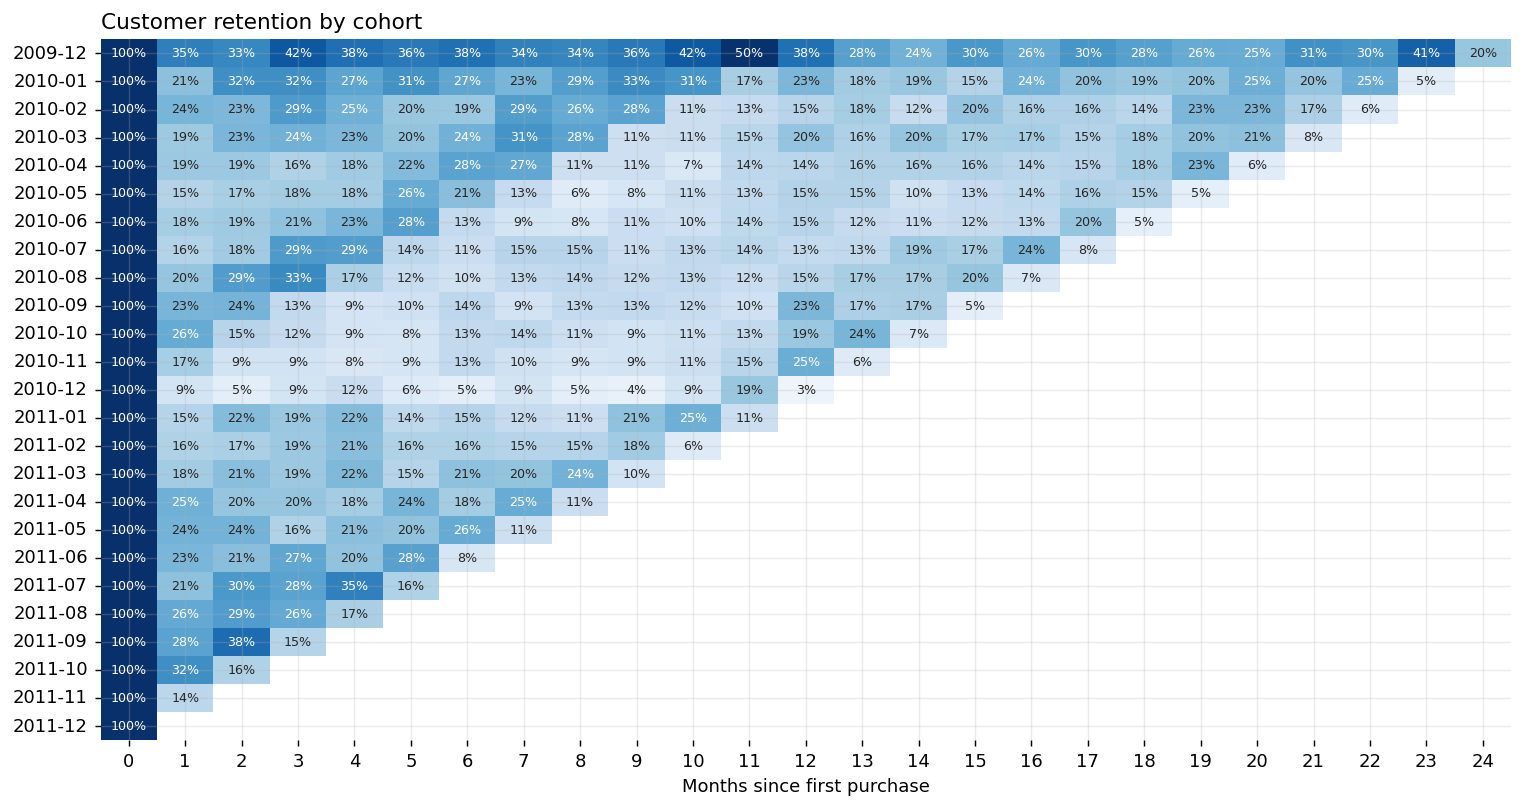

In [35]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=0.5,
            cbar=False, annot_kws={"size": 7}, ax=ax)

ax.set_title("Customer retention by cohort", loc="left")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("")
fig.savefig(OUT / "cohort_retention.png", bbox_inches="tight")

In [36]:
rev_cohorts = known.groupby(["cohort", "cohort_index"])["Revenue"].sum().unstack()
rev_retention = rev_cohorts.divide(rev_cohorts[0], axis=0)

print(rev_retention.iloc[1:8, :8].round(2))

cohort_index    0     1     2     3     4     5     6     7
cohort                                                     
2010-01       1.0  0.24  0.31  0.36  0.36  0.38  0.32  0.29
2010-02       1.0  0.20  0.32  0.32  0.26  0.24  0.23  0.31
2010-03       1.0  0.23  0.25  0.26  0.24  0.26  0.31  0.39
2010-04       1.0  0.15  0.17  0.19  0.18  0.25  0.28  0.27
2010-05       1.0  0.12  0.13  0.12  0.15  0.28  0.21  0.12
2010-06       1.0  0.13  0.18  0.21  0.28  0.38  0.20  0.14
2010-07       1.0  0.11  0.19  0.34  0.39  0.32  0.12  0.15


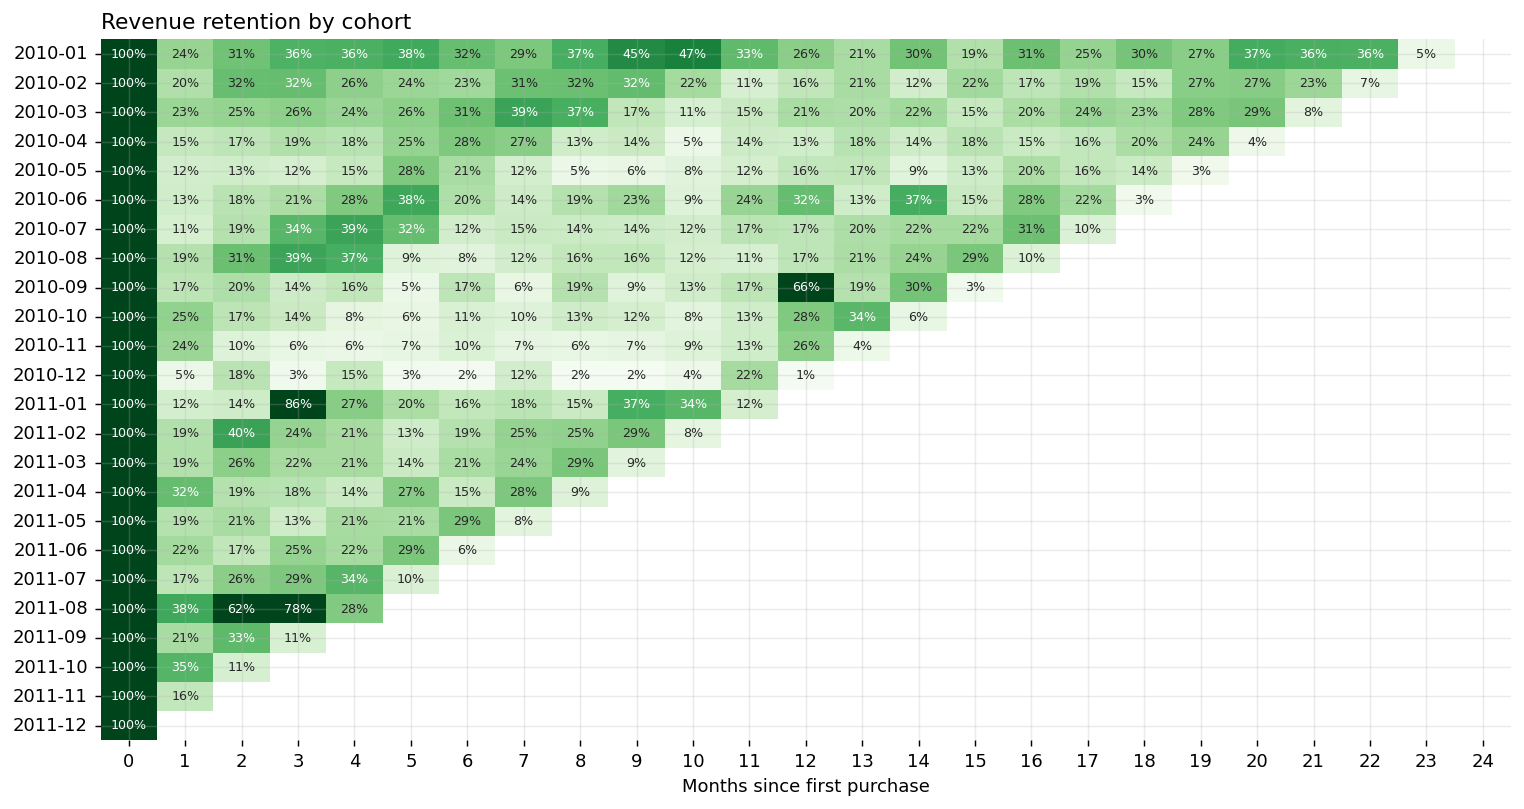

In [37]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(rev_retention.iloc[1:], annot=True, fmt=".0%", cmap="Greens",
            vmin=0, vmax=0.6, cbar=False, annot_kws={"size": 7}, ax=ax)
ax.set_title("Revenue retention by cohort", loc="left")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("")
fig.savefig(OUT / "revenue_retention.png", bbox_inches="tight")

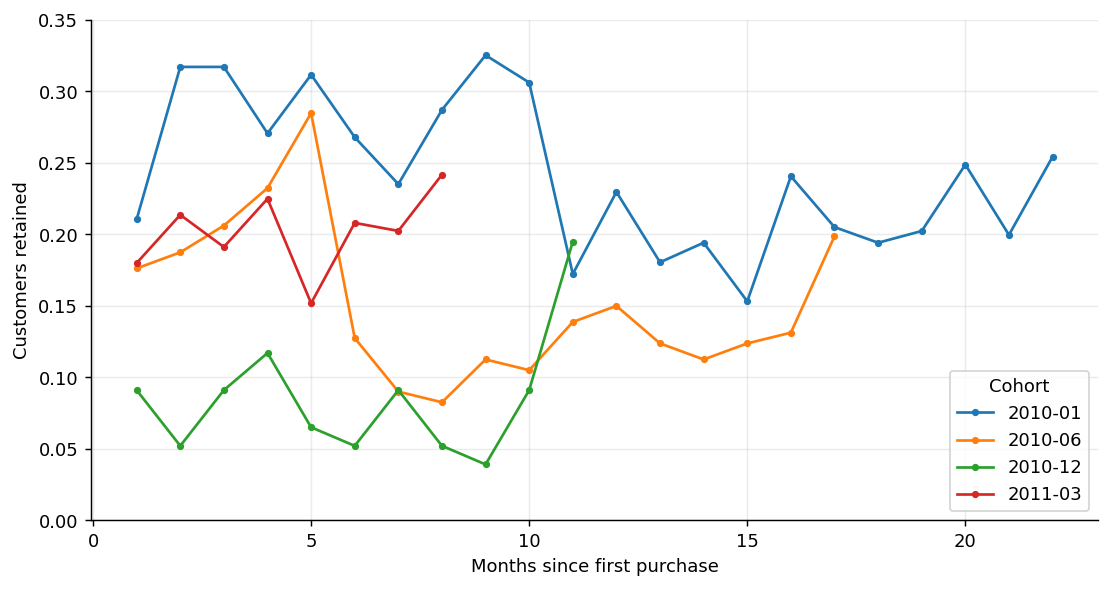

In [38]:
picks = ["2010-01", "2010-06", "2010-12", "2011-03"]

fig, ax = plt.subplots(figsize=(10, 5))
for p in picks:
    row = retention.loc[p].dropna().iloc[1:-1]
    ax.plot(row.index, row.values, marker="o", markersize=3, label=p)

ax.set_ylim(0, 0.35)
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Customers retained")
ax.legend(title="Cohort")
fig.savefig(OUT / "retention_curves.png", bbox_inches="tight")

##**RFM Segmentation**

In [39]:
snapshot = known["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = known.groupby("Customer ID").agg(
    recency=("InvoiceDate", lambda d: (snapshot - d.max()).days),
    frequency=("Invoice", "nunique"),
    monetary=("Revenue", "sum"),
)

print(snapshot)
print(rfm.describe().round(1))

2011-12-10 12:50:00
       recency  frequency  monetary
count   5839.0     5839.0    5839.0
mean     200.4        6.2    2882.8
std      208.6       12.6   14180.6
min        1.0        1.0       2.9
25%       26.0        1.0     342.0
50%       95.0        3.0     874.6
75%      379.0        7.0    2251.7
max      739.0      369.0  606963.2


In [40]:
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5])

print(rfm.groupby("r_score")["recency"].agg(["min", "max", "size"]))
print(rfm.groupby("f_score")["frequency"].agg(["min", "max", "size"]))
print(rfm.groupby("m_score")["monetary"].agg(["min", "max", "size"]))

         min  max  size
r_score                
5          1   19  1184
4         20   59  1172
3         60  187  1151
2        188  409  1172
1        410  739  1160
         min  max  size
f_score                
1          1    1  1168
2          1    2  1168
3          2    4  1167
4          4    8  1168
5          8  369  1168
             min        max  size
m_score                          
1           2.90     285.11  1168
2         285.30     608.79  1168
3         608.86    1214.07  1167
4        1214.72    2912.38  1168
5        2919.65  606963.25  1168


/tmp/ipykernel_559/1115461661.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rfm.groupby("r_score")["recency"].agg(["min", "max", "size"]))
/tmp/ipykernel_559/1115461661.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rfm.groupby("f_score")["frequency"].agg(["min", "max", "size"]))
/tmp/ipykernel_559/1115461661.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rfm.groupby("m_score")["monetary

In [41]:
rfm[["r_score", "f_score", "m_score"]] = rfm[["r_score", "f_score", "m_score"]].astype(int)

def label(row):
    r, f = row["r_score"], row["f_score"]
    if r >= 4 and f >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal"
    if r >= 4 and f <= 2:
        return "New"
    if r <= 2 and f >= 3:
        return "At Risk"
    return "Hibernating"

rfm["segment"] = rfm.apply(label, axis=1)
print(rfm["segment"].value_counts())

segment
Hibernating    1888
Champions      1477
Loyal          1203
At Risk         823
New             448
Name: count, dtype: int64


In [42]:
seg = rfm.groupby("segment").agg(
    customers=("monetary", "size"),
    revenue=("monetary", "sum"),
    avg_value=("monetary", "mean"),
    med_value=("monetary", "median"),
    avg_orders=("frequency", "mean"),
    avg_recency=("recency", "mean"),
)
seg["rev_share"] = seg["revenue"] / seg["revenue"].sum()
seg["cust_share"] = seg["customers"] / seg["customers"].sum()

print(seg.sort_values("revenue", ascending=False).round(1))
print((seg[["rev_share", "cust_share"]] * 100).round(1))

             customers     revenue  avg_value  med_value  avg_orders  \
segment                                                                
Champions         1477  11881376.6     8044.3     3409.7        15.4   
Loyal             1203   2370194.0     1970.2     1194.7         5.3   
At Risk            823   1472444.8     1789.1     1015.7         4.9   
Hibernating       1888    859751.8      455.4      295.9         1.3   
New                448    248829.3      555.4      365.8         1.5   

             avg_recency  rev_share  cust_share  
segment                                          
Champions           20.4        0.7         0.3  
Loyal               78.4        0.1         0.2  
At Risk            369.7        0.1         0.1  
Hibernating        385.9        0.1         0.3  
New                 28.2        0.0         0.1  
             rev_share  cust_share
segment                           
At Risk            8.7        14.1
Champions         70.6        25.3
Hiber

##**Market Baskets**

In [43]:
basket = known[["Invoice", "StockCode", "Description"]].drop_duplicates()

inv_count = basket["Invoice"].nunique()
item_freq = basket.groupby("StockCode")["Invoice"].nunique().sort_values(ascending=False)

print(inv_count, basket["StockCode"].nunique())
print((item_freq / inv_count).head(10).round(3))
print((item_freq >= 100).sum(), (item_freq >= 200).sum())

36333 4611
StockCode
85123A    0.134
85099B    0.089
22423     0.088
84879     0.073
20725     0.071
21212     0.069
47566     0.057
22383     0.055
20727     0.055
22382     0.053
Name: Invoice, dtype: float64
1843 1095


In [44]:
from itertools import combinations
from collections import Counter

keep = set(item_freq[item_freq >= 200].index)
b = basket[basket["StockCode"].isin(keep)]

invoices = b.groupby("Invoice")["StockCode"].apply(list)
pair_counts = Counter()
for items in invoices:
    if 1 < len(items) <= 60:
        pair_counts.update(combinations(sorted(set(items)), 2))

print(len(invoices), len(pair_counts))

35292 558778


In [45]:
n = len(invoices)
freq = invoices.explode().value_counts()

rules = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counts.items() if c >= 50],
    columns=["a", "b", "pair_count"],
)
rules["support"] = rules["pair_count"] / n
rules["conf_a_to_b"] = rules["pair_count"] / rules["a"].map(freq)
rules["conf_b_to_a"] = rules["pair_count"] / rules["b"].map(freq)
rules["lift"] = rules["support"] / ((rules["a"].map(freq) / n) * (rules["b"].map(freq) / n))

print(len(rules))
print(rules["lift"].describe().round(2))

13422
count    13422.00
mean         4.94
std          8.41
min          0.41
25%          1.41
50%          2.16
75%          4.43
max        117.34
Name: lift, dtype: float64


In [46]:
names = basket.drop_duplicates("StockCode").set_index("StockCode")["Description"]

rules["name_a"] = rules["a"].map(names)
rules["name_b"] = rules["b"].map(names)

top = rules.sort_values("lift", ascending=False).head(20)
print(top[["name_a", "name_b", "pair_count", "support", "conf_a_to_b", "lift"]].to_string(index=False))

                          name_a                              name_b  pair_count  support  conf_a_to_b       lift
        CHILDS GARDEN BRUSH BLUE            CHILDS GARDEN BRUSH PINK         135 0.003825     0.671642 117.344466
        REGENCY TEA PLATE GREEN               REGENCY TEA PLATE PINK         182 0.005157     0.676580 107.075600
    CHILDRENS GARDEN GLOVES BLUE        CHILDRENS GARDEN GLOVES PINK         163 0.004619     0.705628 104.196707
        REGENCY SUGAR BOWL GREEN              REGENCY MILK JUG PINK          193 0.005469     0.725564  94.489304
           JAM JAR WITH PINK LID               JAM JAR WITH BLUE LID         144 0.004080     0.560311  89.884117
            MIRRORED DISCO BALL  DISCO BALL ROTATOR BATTERY OPERATED         139 0.003939     0.512915  87.027888
        REGENCY TEA PLATE ROSES               REGENCY TEA PLATE PINK         176 0.004987     0.541538  85.703925
PINK UNION JACK  PASSPORT COVER         PINK UNION JACK  LUGGAGE TAG          97 0.00274

In [47]:
def overlap(row):
    wa, wb = set(row["name_a"].split()), set(row["name_b"].split())
    return len(wa & wb) / min(len(wa), len(wb))

rules["name_overlap"] = rules.apply(overlap, axis=1)
cross = rules[(rules["name_overlap"] < 0.5) & (rules["lift"] > 3)].copy()
cross["score"] = cross["lift"] * cross["support"]

top = cross.sort_values("score", ascending=False).head(20)
print(top[["name_a", "name_b", "pair_count", "support", "conf_a_to_b", "lift"]].to_string(index=False))

                          name_a                             name_b  pair_count  support  conf_a_to_b      lift
        REGENCY SUGAR BOWL GREEN             REGENCY MILK JUG PINK          193 0.005469     0.725564 94.489304
           REGENCY TEAPOT ROSES            REGENCY SUGAR BOWL GREEN         179 0.005072     0.508523 67.469113
           REGENCY TEAPOT ROSES              REGENCY MILK JUG PINK          179 0.005072     0.508523 66.224296
       CHILDS GARDEN TROWEL PINK       CHILDRENS GARDEN GLOVES BLUE         139 0.003939     0.430341 65.747095
      CINAMMON SET OF 9 T-LIGHTS      ORANGE SCENTED SET/9 T-LIGHTS         123 0.003485     0.430070 73.323807
 BOYS VINTAGE TIN SEASIDE BUCKET             RED METAL BEACH SPADE          148 0.004194     0.485246 55.782731
      CHILDS GARDEN TROWEL BLUE        CHILDRENS GARDEN GLOVES PINK         131 0.003712     0.401840 59.337885
       RETRO SPOT SUGAR JAM BOWL          RETRO SPOT SMALL MILK JUG         351 0.009946     0.577303 21

In [48]:
cand = top.head(5)
item_rev = known.groupby("StockCode")["Revenue"].sum() / known.groupby("StockCode")["Invoice"].nunique()

for _, r in cand.iterrows():
    a_only = rules.loc[(rules["a"] == r["a"]) & (rules["b"] == r["b"]), "pair_count"].iloc[0]
    a_total = freq[r["a"]]
    missed = a_total - a_only
    uplift = missed * 0.15 * item_rev[r["b"]]
    print(r["name_a"][:28], "->", r["name_b"][:28], int(missed), round(uplift))

REGENCY SUGAR BOWL GREEN -> REGENCY MILK JUG PINK  73 359
REGENCY TEAPOT ROSES  -> REGENCY SUGAR BOWL GREEN 173 1111
REGENCY TEAPOT ROSES  -> REGENCY MILK JUG PINK  173 850
CHILDS GARDEN TROWEL PINK -> CHILDRENS GARDEN GLOVES BLUE 184 256
CINAMMON SET OF 9 T-LIGHTS -> ORANGE SCENTED SET/9 T-LIGHT 163 139


In [49]:
cross["missed"] = cross["a"].map(freq) - cross["pair_count"]
cross["b_value"] = cross["b"].map(item_rev)
cross["opportunity"] = cross["missed"] * cross["b_value"] * 0.15

best = cross.sort_values("opportunity", ascending=False).head(10)
print(best[["name_a", "name_b", "missed", "b_value", "conf_a_to_b", "lift", "opportunity"]].round(2).to_string(index=False))
print(best["opportunity"].sum())

                           name_a                              name_b  missed  b_value  conf_a_to_b  lift  opportunity
         REGENCY CAKESTAND 3 TIER               REGENCY TEAPOT ROSES     3039    64.97         0.05  5.25     29614.41
         REGENCY CAKESTAND 3 TIER            REGENCY SUGAR BOWL GREEN    3074    42.82         0.04  5.50     19746.50
  PAPER CHAIN KIT 50'S CHRISTMAS  ROTATING SILVER ANGELS T-LIGHT HLDR    1599    80.20         0.05  3.25     19236.37
         REGENCY CAKESTAND 3 TIER            REGENCY TEA PLATE GREEN     3098    33.89         0.03  4.46     15746.77
         REGENCY CAKESTAND 3 TIER              REGENCY MILK JUG PINK     3082    32.75         0.04  5.08     15141.60
         REGENCY CAKESTAND 3 TIER            REGENCY TEA PLATE ROSES     3079    30.87         0.04  4.33     14255.95
PAPER CHAIN KIT VINTAGE CHRISTMAS ROTATING SILVER ANGELS T-LIGHT HLDR    1165    80.20         0.05  3.20     14015.24
   STRAWBERRY CERAMIC TRINKET BOX     TEA TIME C

##**Root Cause Analysis**

In [50]:
window = ["2011-02", "2011-03", "2011-04", "2011-05"]
w = monthly.loc[window]

w = w.copy()
w["items_per_order"] = known.groupby("month").apply(lambda g: len(g) / g["Invoice"].nunique()).loc[window]
w["units_per_order"] = known.groupby("month")["Quantity"].sum().loc[window] / w["orders"]
w["price_per_unit"] = w["revenue"] / known.groupby("month")["Quantity"].sum().loc[window]

print(w.round(2))

           revenue  orders  customers     aov  items_per_order  \
month                                                            
2011-02  440261.06     987        756  446.06            19.98   
2011-03  577035.90    1303        970  442.85            20.54   
2011-04  449412.27    1129        848  398.06            19.84   
2011-05  653179.21    1528       1051  427.47            18.32   

         units_per_order  price_per_unit  
month                                     
2011-02           267.86            1.67  
2011-03           264.60            1.67  
2011-04           256.79            1.55  
2011-05           241.88            1.77  


/tmp/ipykernel_559/1473677165.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  w["items_per_order"] = known.groupby("month").apply(lambda g: len(g) / g["Invoice"].nunique()).loc[window]


In [51]:
mar = known[known["month"] == "2011-03"]
apr = known[known["month"] == "2011-04"]

by_country = pd.DataFrame({
    "mar": mar.groupby("Country")["Revenue"].sum(),
    "apr": apr.groupby("Country")["Revenue"].sum(),
}).fillna(0)
by_country["change"] = by_country["apr"] - by_country["mar"]

print(by_country.sort_values("change").head(8).round(0))
print(by_country["change"].sum().round(0))

                     mar       apr   change
Country                                    
United Kingdom  459447.0  401320.0 -58127.0
Netherlands      22206.0    2887.0 -19320.0
Australia        17211.0     422.0 -16789.0
EIRE             17833.0    7270.0 -10563.0
France           13642.0    3824.0  -9818.0
Sweden            4681.0     649.0  -4031.0
Denmark           3979.0       0.0  -3979.0
Finland           4866.0    1369.0  -3497.0
-127624.0


In [52]:
export = ["Netherlands", "Australia", "EIRE", "France", "Sweden", "Denmark", "Finland"]

e_mar = mar[mar["Country"].isin(export)].groupby("Customer ID")["Revenue"].sum()
e_apr = apr[apr["Country"].isin(export)].groupby("Customer ID")["Revenue"].sum()

comp = pd.DataFrame({"mar": e_mar, "apr": e_apr}).fillna(0)
comp["change"] = comp["apr"] - comp["mar"]

print(len(e_mar), len(e_apr))
print(comp.sort_values("change").head(10).round(0))

31 22
                 mar     apr   change
Customer ID                          
14646        21327.0  2887.0 -18441.0
12415        16727.0     0.0 -16727.0
14156         9695.0  2898.0  -6796.0
12428         4866.0   254.0  -4612.0
17404         4523.0     0.0  -4523.0
12435         3979.0     0.0  -3979.0
12678         3243.0     0.0  -3243.0
14911         6661.0  4372.0  -2289.0
12731         2334.0   177.0  -2157.0
14016         1478.0     0.0  -1478.0


In [53]:
key = ["14646", "12415", "14156"]
hist = known[known["Customer ID"].isin(key)].groupby(["Customer ID", "month"])["Revenue"].sum().unstack(0).fillna(0)

print(hist.loc["2010-11":"2011-09"].round(0))

Customer ID    12415    14156    14646
month                                 
2010-11      16555.0  10566.0  32710.0
2010-12          0.0    644.0   8577.0
2011-01       7093.0  14226.0  26477.0
2011-02      13598.0   8655.0  22647.0
2011-03      16727.0   9695.0  21327.0
2011-04          0.0   2898.0   2887.0
2011-05      12691.0   5412.0  28240.0
2011-06      23427.0   9708.0  25289.0
2011-07       2796.0  26365.0     11.0
2011-08      21706.0   4822.0  39932.0
2011-09       2942.0  19479.0  26661.0


###**Root Cause Analysis on the drop of Revenue in April 2011**

Revenue was £449k in April, down from £577k in March and down 22% on April 2010. AOV was £398, the lowest in the dataset.

I broke revenue into orders, units per order, and price per unit. Orders fell 13.4%. Basket size barely moved, 20.5 items per order down to 19.8, and units per order 265 down to 257. Price per unit fell from £1.67 to £1.55.

So people weren't buying less per order, they were buying cheaper things, and fewer of them were ordering at all. Customer count fell 12.6%, roughly in line with the order drop, which means orders per customer stayed normal.

Splitting by country was where it got interesting. The UK is 92% of revenue but only 46% of the loss. The export markets didn't soften, they stopped. Netherlands fell 87%, Australia 98%, Denmark went to zero. Export customer count went from 31 in March to 22 in April.

Going one level further, two accounts explain £35,168 of the £127,624 gap. Customer 14646 in the Netherlands dropped from £21,327 to £2,887. Customer 12415 in Australia dropped from £16,727 to nothing. The entire Netherlands decline and the entire Australia decline are one customer each, showing high dependency on export clients.

I then pulled both accounts' full monthly history. Both came back in May with orders of £28,240 and £12,691 and neither shows any downward trend across 2011. Both have skipped months before: 12415 ordered nothing in December 2010 and only £2,796 in July 2011, then £21,706 in August.

So there's no underlying cause. Two big wholesale accounts happened not to order in the same month. The price-per-unit drop came from losing those bulk export orders, not from anything separate.

The more useful takeaway is about how this business should report. 58 customers drive 31% of revenue and wholesale buyers reorder every four to eight weeks, so monthly revenue is mostly a function of who happened to place an order. Any given month can look like a crisis or a record depending on timing. Monthly revenue isn't a reliable performance signal here — a rolling 90-day view, or tracking order frequency per account, would be.

In [54]:
BASE = Path("/content/drive/MyDrive/ecommerce-analytics")
BASE.mkdir(parents=True, exist_ok=True)

known.to_parquet(BASE / "known_clean.parquet")
df.to_parquet(BASE / "all_clean.parquet")
rfm.to_parquet(BASE / "rfm.parquet")
rules.to_parquet(BASE / "rules.parquet")

In [55]:
sql_df = known.drop(columns=["month", "cohort", "cohort_index", "is_new", "has_id"], errors="ignore").copy()
sql_df.columns = [c.replace(" ", "_") for c in sql_df.columns]
sql_df.to_csv(BASE / "transactions.csv", index=False)

print(len(sql_df), sql_df.columns.tolist())

796429 ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'Revenue']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')